In [1]:
import pandas as pd
import numpy as np

print("Libraries loaded")

Libraries loaded


In [2]:
df = pd.read_csv("ML_analysis_mushrooms.csv")

df.head()

,Sample_ID,Species,Pre_treatment,Probiotic,ABTS,DPPH,FRAP,TPC,Vit_B1,Vit_B2,Beta_glucan,Texture,Delta_H,Sensory_score
0,S1,A_bisporus,No_pretreatment,No_inoculation,219.96,21.99,16.63,195.33,616.42,797.66,9.55,12.90,87.84,4.4
1,S2,A_bisporus,No_pretreatment,No_inoculation,218.28,22.92,17.11,203.72,737.67,826.63,9.66,12.19,87.63,4.4
2,S3,A_bisporus,No_pretreatment,No_inoculation,210.96,19.23,15.93,213.26,764.35,998.02,9.44,13.97,87.70,4.4
3,S4,A_bisporus,No_pretreatment,No_inoculation,230.09,21.99,14.19,156.42,539.84,509.11,10.43,14.43,83.81,4.4
4,S5,A_bisporus,No_pretreatment,No_inoculation,229.53,20.46,14.77,155.65,486.30,453.35,10.30,12.06,83.47,4.4


In [3]:
df.shape

(204, 14)

In [4]:
df.dtypes

Sample_ID         object
Species           object
Pre_treatment     object
Probiotic         object
ABTS             float64
DPPH             float64
FRAP             float64
TPC              float64
Vit_B1           float64
Vit_B2           float64
Beta_glucan      float64
Texture          float64
Delta_H          float64
Sensory_score    float64
dtype: object

In [5]:
df_encoded = pd.get_dummies(df, columns=["Species", "Pre_treatment", "Probiotic"])

df_encoded.head()

,Sample_ID,ABTS,DPPH,FRAP,TPC,Vit_B1,Vit_B2,Beta_glucan,Texture,Delta_H,...,Species_A_bisporus,Species_I_badia,Species_L_deliciosus,Pre_treatment_MB_2m,Pre_treatment_No_pretreatment,Pre_treatment_WB_2m,Pre_treatment_WB_30s,Probiotic_LA5,Probiotic_No_inoculation,Probiotic_PL
0,S1,219.96,21.99,16.63,195.33,616.42,797.66,9.55,12.90,87.84,...,True,False,False,False,True,False,False,False,True,False
1,S2,218.28,22.92,17.11,203.72,737.67,826.63,9.66,12.19,87.63,...,True,False,False,False,True,False,False,False,True,False
2,S3,210.96,19.23,15.93,213.26,764.35,998.02,9.44,13.97,87.70,...,True,False,False,False,True,False,False,False,True,False
3,S4,230.09,21.99,14.19,156.42,539.84,509.11,10.43,14.43,83.81,...,True,False,False,False,True,False,False,False,True,False
4,S5,229.53,20.46,14.77,155.65,486.30,453.35,10.30,12.06,83.47,...,True,False,False,False,True,False,False,False,True,False


In [6]:
df_encoded = df_encoded.drop(columns=["Sample_ID"])

In [7]:
X = df_encoded.drop(columns=[
    "ABTS", "DPPH", "FRAP", "TPC",
    "Vit_B1", "Vit_B2", "Beta_glucan",
    "Texture", "Delta_H", "Sensory_score"
])

y = df_encoded[[
    "ABTS", "DPPH", "FRAP", "TPC",
    "Vit_B1", "Vit_B2", "Beta_glucan",
    "Texture", "Delta_H", "Sensory_score"
]]

In [8]:
print(X.shape)
print(y.shape)

(204, 10)
(204, 10)


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(163, 10) (41, 10)


In [10]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

<class 'ValueError'>: Input y contains NaN.

In [11]:
y.isna().sum()

ABTS             24
DPPH             24
FRAP             24
TPC              24
Vit_B1           24
Vit_B2           24
Beta_glucan      24
Texture          24
Delta_H          24
Sensory_score    24
dtype: int64

In [12]:
df_encoded = df_encoded.dropna()

In [13]:
X = df_encoded.drop(columns=[
    "ABTS", "DPPH", "FRAP", "TPC",
    "Vit_B1", "Vit_B2", "Beta_glucan",
    "Texture", "Delta_H", "Sensory_score"
])

y = df_encoded[[
    "ABTS", "DPPH", "FRAP", "TPC",
    "Vit_B1", "Vit_B2", "Beta_glucan",
    "Texture", "Delta_H", "Sensory_score"
]]

In [14]:
print(X.shape)
print(y.shape)

(180, 10)
(180, 10)


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [16]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [17]:
y_pred = model.predict(X_test)

In [18]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R2:", r2)
print("RMSE:", rmse)

R2: 0.6997863533925961
RMSE: 273.57127467230185


In [19]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

feature_importance

,Feature,Importance
2,Species_L_deliciosus,0.525035
5,Pre_treatment_WB_2m,0.164763
6,Pre_treatment_WB_30s,0.058321
1,Species_I_badia,0.050310
8,Probiotic_No_inoculation,0.049042
0,Species_A_bisporus,0.040007
4,Pre_treatment_No_pretreatment,0.036695
3,Pre_treatment_MB_2m,0.033467
9,Probiotic_PL,0.028838
7,Probiotic_LA5,0.013523


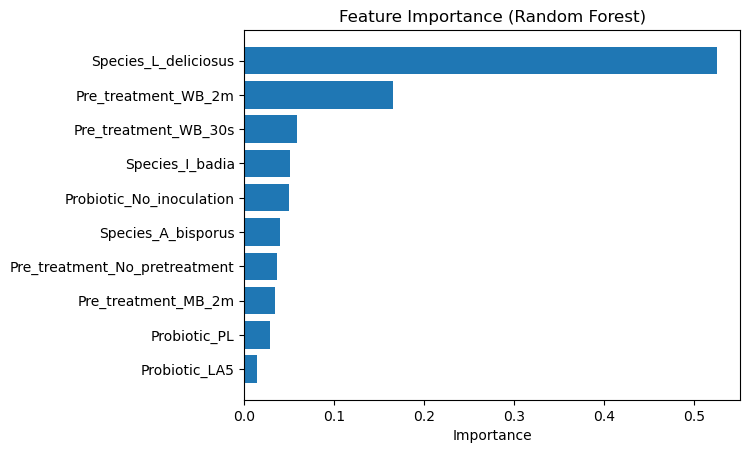

In [20]:
import matplotlib.pyplot as plt

feature_importance_sorted = feature_importance.sort_values(by="Importance")

plt.figure()
plt.barh(feature_importance_sorted["Feature"], feature_importance_sorted["Importance"])
plt.xlabel("Importance")
plt.title("Feature Importance (Random Forest)")
plt.show()

In [21]:
species_importance = feature_importance[feature_importance["Feature"].str.contains("Species")]["Importance"].sum()
pretreatment_importance = feature_importance[feature_importance["Feature"].str.contains("Pre_treatment")]["Importance"].sum()
probiotic_importance = feature_importance[feature_importance["Feature"].str.contains("Probiotic")]["Importance"].sum()

print("Species:", species_importance)
print("Pre-treatment:", pretreatment_importance)
print("Probiotic:", probiotic_importance)

Species: 0.6153519039124827
Pre-treatment: 0.293244836489616
Probiotic: 0.0914032595979011


In [22]:
df_grouped = df.groupby(
    ["Species", "Pre_treatment", "Probiotic"]
).mean(numeric_only=True).reset_index()

df_grouped.head()

,Species,Pre_treatment,Probiotic,ABTS,DPPH,FRAP,TPC,Vit_B1,Vit_B2,Beta_glucan,Texture,Delta_H,Sensory_score
0,A_bisporus,MB_2m,LA5,114.161667,12.380000,13.471667,99.861667,660.531667,2842.991667,11.306667,18.828333,74.701667,3.8
1,A_bisporus,MB_2m,No_inoculation,116.300000,11.303333,12.523333,113.865000,751.916667,3074.116667,9.301667,19.810000,84.760000,4.0
2,A_bisporus,MB_2m,PL,108.761667,8.558333,11.991667,101.101667,837.186667,3643.286667,7.470000,17.411667,77.233333,4.1
3,A_bisporus,No_pretreatment,No_inoculation,224.370000,21.430000,15.401667,180.260000,596.936667,671.501667,9.988333,13.435000,85.698333,4.4
4,A_bisporus,WB_2m,LA5,122.863333,10.653333,12.658333,124.765000,759.761667,3698.356667,9.345000,26.245000,80.208333,4.0


In [23]:
df_grouped["Antioxidant_total"] = df_grouped["ABTS"] + df_grouped["DPPH"] + df_grouped["FRAP"]

best_antiox = df_grouped.loc[df_grouped.groupby("Species")["Antioxidant_total"].idxmax()]

best_antiox[["Species", "Pre_treatment", "Probiotic", "Antioxidant_total"]]

,Species,Pre_treatment,Probiotic,Antioxidant_total
9,A_bisporus,WB_30s,PL,296.005000
17,I_badia,WB_30s,LA5,230.946667
20,L_deliciosus,MB_2m,LA5,169.156667


In [25]:
best_B1 = df_grouped.loc[df_grouped.groupby("Species")["Vit_B1"].idxmax()]
best_B2 = df_grouped.loc[df_grouped.groupby("Species")["Vit_B2"].idxmax()]

In [26]:
best_beta = df_grouped.loc[df_grouped.groupby("Species")["Beta_glucan"].idxmax()]

In [27]:
df_grouped["Sensory_index"] = (
    df_grouped["Texture"] + df_grouped["Sensory_score"]
)

In [28]:
best_B1 = df_grouped.loc[
    df_grouped.groupby("Species")["Vit_B1"].idxmax()
]

best_B1[["Species", "Pre_treatment", "Probiotic", "Vit_B1"]]

,Species,Pre_treatment,Probiotic,Vit_B1
2,A_bisporus,MB_2m,PL,837.186667
18,I_badia,WB_30s,No_inoculation,866.964167
21,L_deliciosus,MB_2m,No_inoculation,2570.973333


In [29]:
best_B2 = df_grouped.loc[
    df_grouped.groupby("Species")["Vit_B2"].idxmax()
]

best_B2[["Species", "Pre_treatment", "Probiotic", "Vit_B2"]]

,Species,Pre_treatment,Probiotic,Vit_B2
6,A_bisporus,WB_2m,PL,4100.031667
18,I_badia,WB_30s,No_inoculation,2960.421667
21,L_deliciosus,MB_2m,No_inoculation,6148.575000


In [30]:
best_sensory = df_grouped.loc[
    df_grouped.groupby("Species")["Sensory_index"].idxmax()
]

best_sensory[["Species", "Pre_treatment", "Probiotic", "Sensory_index"]]

,Species,Pre_treatment,Probiotic,Sensory_index
4,A_bisporus,WB_2m,LA5,30.245000
15,I_badia,WB_2m,No_inoculation,12.521667
21,L_deliciosus,MB_2m,No_inoculation,11.701667


In [31]:
!pip install statsmodels

<class 'OSError'>: Not available

In [32]:
from scipy.stats import f_oneway

# Filter one species
df_ab = df[df["Species"] == "A_bisporus"]

# Compare pre-treatments (ignore probiotic for now)
groups = [
    group["ABTS"].values
    for name, group in df_ab.groupby("Pre_treatment")
]

f_stat, p_value = f_oneway(*groups)

print("F-stat:", f_stat)
print("p-value:", p_value)

F-stat: 170.8443901649667
p-value: 3.7686281124199045e-28


In [33]:
groups = [
    group["DPPH"].values
    for name, group in df_ab.groupby("Pre_treatment")
]

f_stat, p_value = f_oneway(*groups)

print("F-stat:", f_stat)
print("p-value:", p_value)

F-stat: 37.0171011378674
p-value: 2.5486862905887325e-13


In [34]:
groups = [
    group["FRAP"].values
    for name, group in df_ab.groupby("Pre_treatment")
]

f_stat, p_value = f_oneway(*groups)

print("F-stat:", f_stat)
print("p-value:", p_value)

F-stat: 16.293986748120712
p-value: 9.862583591799387e-08


In [35]:
df_ib = df[df["Species"] == "I_badia"]

groups = [
    group["ABTS"].values
    for name, group in df_ib.groupby("Pre_treatment")
]

f_stat, p_value = f_oneway(*groups)

print("F-stat:", f_stat)
print("p-value:", p_value)

F-stat: 5.093834329032277
p-value: 0.0030675094383648045


In [36]:
groups = [
    group["DPPH"].values
    for name, group in df_ib.groupby("Pre_treatment")
]

f_stat, p_value = f_oneway(*groups)

print("F-stat:", f_stat)
print("p-value:", p_value)

F-stat: 5.710246186560484
p-value: 0.0015135012115768222


In [37]:
groups = [
    group["FRAP"].values
    for name, group in df_ib.groupby("Pre_treatment")
]

f_stat, p_value = f_oneway(*groups)

print("F-stat:", f_stat)
print("p-value:", p_value)

F-stat: 2.655330526868144
p-value: 0.05535358492246739


In [38]:
df_ld = df[df["Species"] == "L_deliciosus"]

groups = [
    group["ABTS"].values
    for name, group in df_ld.groupby("Pre_treatment")
]

f_stat, p_value = f_oneway(*groups)

print("F-stat:", f_stat)
print("p-value:", p_value)


F-stat: 6.273638084483979
p-value: 0.003951156036830346


In [39]:
groups = [
    group["DPPH"].values
    for name, group in df_ld.groupby("Pre_treatment")
]

f_stat, p_value = f_oneway(*groups)

print("F-stat:", f_stat)
print("p-value:", p_value)

F-stat: 0.4893674625820385
p-value: 0.6162382622099074


In [40]:
groups = [
    group["FRAP"].values
    for name, group in df_ld.groupby("Pre_treatment")
]

f_stat, p_value = f_oneway(*groups)

print("F-stat:", f_stat)
print("p-value:", p_value)

F-stat: 54.48373013105059
p-value: 9.552790963431115e-13


In [41]:
groups = [
    group["Vit_B1"].values
    for name, group in df_ab.groupby("Pre_treatment")
]

from scipy.stats import f_oneway

f_stat, p_value = f_oneway(*groups)

print("F-stat:", f_stat)
print("p-value:", p_value)

F-stat: 4.036708346216588
p-value: 0.011411481000559746


In [42]:
groups = [
    group["Vit_B2"].values
    for name, group in df_ab.groupby("Pre_treatment")
]

f_stat, p_value = f_oneway(*groups)

print("F-stat:", f_stat)
print("p-value:", p_value)

F-stat: 91.18180444818093
p-value: 1.5506060502577752e-21


In [43]:
groups = [
    group["Vit_B1"].values
    for name, group in df_ib.groupby("Pre_treatment")
]

f_stat, p_value = f_oneway(*groups)

print("F-stat:", f_stat)
print("p-value:", p_value)

F-stat: 4.250613232733217
p-value: 0.008208145225368502


In [44]:
groups = [
    group["Vit_B2"].values
    for name, group in df_ib.groupby("Pre_treatment")
]

f_stat, p_value = f_oneway(*groups)

print("F-stat:", f_stat)
print("p-value:", p_value)

F-stat: 4.412144741064189
p-value: 0.006787258011741003


In [45]:
groups = [
    group["Vit_B1"].values
    for name, group in df_ld.groupby("Pre_treatment")
]

f_stat, p_value = f_oneway(*groups)

print("F-stat:", f_stat)
print("p-value:", p_value)

F-stat: 48.86688795721002
p-value: 5.253268216848746e-12


In [46]:
groups = [
    group["Vit_B2"].values
    for name, group in df_ld.groupby("Pre_treatment")
]

f_stat, p_value = f_oneway(*groups)

print("F-stat:", f_stat)
print("p-value:", p_value)

F-stat: 14.269390430108217
p-value: 1.5873108321121626e-05


In [47]:
groups = [
    group["Sensory_index"].values
    for name, group in df_ab.groupby("Pre_treatment")
]

from scipy.stats import f_oneway

f_stat, p_value = f_oneway(*groups)

print("F-stat:", f_stat)
print("p-value:", p_value)

<class 'KeyError'>: 'Sensory_index'

In [1]:
groups = [
    group["Sensory_index"].values
    for name, group in df_ab.groupby("Pre_treatment")
]

from scipy.stats import f_oneway

f_stat, p_value = f_oneway(*groups)

print("F-stat:", f_stat)
print("p-value:", p_value)

<class 'NameError'>: name 'df_ab' is not defined

In [2]:
df_ab = df[df["Species"] == "A_bisporus"]

groups = [
    group["Sensory_index"].values
    for name, group in df_ab.groupby("Pre_treatment")
]

from scipy.stats import f_oneway

f_stat, p_value = f_oneway(*groups)

print("A. bisporus → F:", f_stat, "p:", p_value)

<class 'NameError'>: name 'df' is not defined

In [3]:
df["Sensory_index"] = df["Texture"] + df["Sensory_score"]

<class 'NameError'>: name 'df' is not defined

In [4]:
import pandas as pd


In [5]:
df = pd.read_csv("ML_analysis_mushrooms.csv")

In [6]:
df["Sensory_index"] = df["Texture"] + df["Sensory_score"]

In [7]:
df_ab = df[df["Species"] == "A_bisporus"]

In [8]:
from scipy.stats import f_oneway

groups = [
    group["Sensory_index"].values
    for name, group in df_ab.groupby("Pre_treatment")
]

f_stat, p_value = f_oneway(*groups)

print("A. bisporus → F:", f_stat, "p:", p_value)

A. bisporus → F: 1.904202214013068 p: 0.1393903718859252


In [9]:
df_ib = df[df["Species"] == "I_badia"]

groups = [
    group["Sensory_index"].values
    for name, group in df_ib.groupby("Pre_treatment")
]

from scipy.stats import f_oneway

f_stat, p_value = f_oneway(*groups)

print("I. badia → F:", f_stat, "p:", p_value)

I. badia → F: 8.44209180563193 p: 7.597920513054907e-05


In [10]:
df_ld = df[df["Species"] == "L_deliciosus"]

groups = [
    group["Sensory_index"].values
    for name, group in df_ld.groupby("Pre_treatment")
]

from scipy.stats import f_oneway

f_stat, p_value = f_oneway(*groups)

print("L. deliciosus → F:", f_stat, "p:", p_value)

L. deliciosus → F: 0.3223858912912645 p: 0.7260778024371831
